In [1]:
# This cell does not render in the docs beca
%load_ext autoreload
%autoreload 2

import warnings
from glass_box_umap.plotting import output_notebook

output_notebook(hide_banner=True)
warnings.filterwarnings("ignore")

# Basic Usage

## A drop in replacement for UMAP

In simple cases, glass box UMAP can serve as a drop-in replacement for UMAP.

```diff
- from umap import UMAP
+ from glass_box_umap import GlassBoxUMAP

- UMAP().fit_transform(X)
+ GlassBoxUMAP().fit_transform(X)
```

Let's illustrate this with an example. The [UCI Wine](https://archive.ics.uci.edu/dataset/109/wine) dataset contains chemical measurements of wines from a region in Italy, produced using one of three cultivars (grape varieties). The dataset includes 178 wines (observations), each with measurements across 13 different chemical features and a label indicating which cultivar the wine was produced from.

The dataset can be loaded from [sklearn.datasets](https://scikit-learn.org/stable/api/sklearn.datasets.html).

In [2]:
import pandas as pd
from sklearn.datasets import load_wine

wine, target = load_wine(as_frame=True, return_X_y=True)
wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


The features have different scales and need to be standardized ($\mu = 0$, $\sigma = 1$) before fitting UMAP, so that no single feature dominates the distance metric.

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(wine.values)

# Make sure mean=0 and std=1 for each feature.
assert np.isclose(X.mean(axis=0), np.zeros(X.shape)).all()
assert np.isclose(X.std(axis=0), np.ones(X.shape)).all()

Let's calculate and visualize standard UMAP embeddings using [umap-learn](https://umap-learn.readthedocs.io/en/latest/).

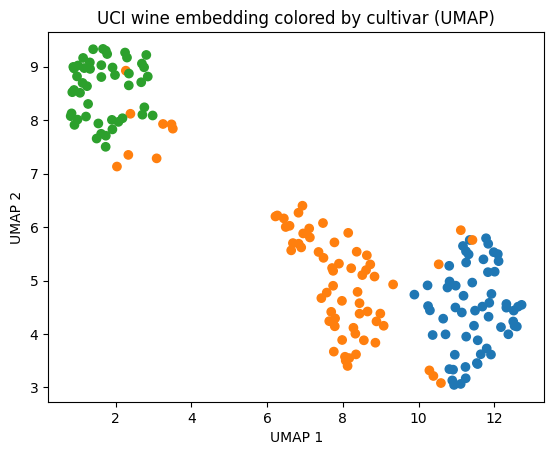

In [4]:
from umap import UMAP
import matplotlib.pyplot as plt

CULTIVAR_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]

umap_embedder = UMAP(random_state=100)
umap_embedder.fit(X)
umap_embedding = umap_embedder.transform(X)

# Sketch up a quick plot
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1], c=[CULTIVAR_COLORS[t] for t in target])
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UCI wine embedding colored by cultivar (UMAP)")
plt.show()

The syntax for glass box UMAP is almost the same.

:::{admonition} GlassBoxUMAP API
:class: api, dropdown

From the [API docs](../autoapi/glass_box_umap/index.rst#glass_box_umap.GlassBoxUMAP):

```{eval-rst}
.. autoclass:: glass_box_umap.GlassBoxUMAP
    :noindex:
```
:::

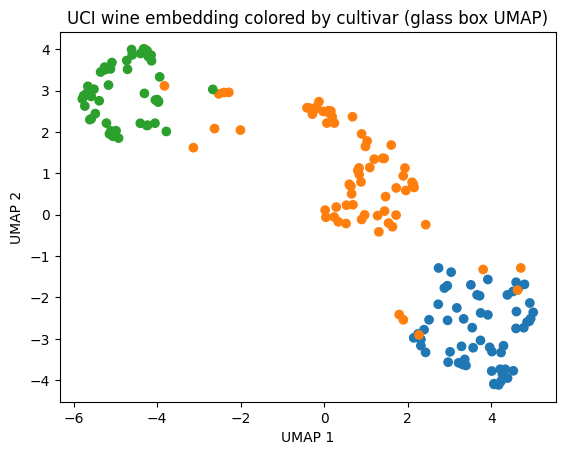

In [5]:
from glass_box_umap import GlassBoxUMAP

gb_umap_embedder = GlassBoxUMAP(random_state=7, epochs=300, quiet=True)
gb_umap_embedder.fit(X)
gb_umap_embedding = gb_umap_embedder.transform(X)

# Sketch up a quick plot
plt.scatter(gb_umap_embedding[:, 0], gb_umap_embedding[:, 1], c=[CULTIVAR_COLORS[t] for t in target])
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UCI wine embedding colored by cultivar (glass box UMAP)")
plt.show()

:::{note}
We don't expect the embeddings to look identical because both algorithms are stochastic. For the sake of visualization, in the above comparion we ran both algorithms several times until their arbitrary orientations qualitatively coincided. For in depth analysis on the comparison between glass box and standard UMAP embeddings, see FIXME.
:::

In the next section we'll discuss feature contributions, something unique to glass box UMAP.

## Feature contributions reconstruct the embedding

:::{note}
Here we focus on the practical aspects of feature contributions. For discussion about the underlying theory, see FIXME and FIXME.
:::

The main feature of Glass Box UMAP is computing feature contributions that attribute how much each feature contributes to each embedding coordinate.

We can readily calculate them with `GlassBoxUMAP.compute_contributions`:

:::{admonition} compute_attributions API
:class: api, dropdown

From the [API docs](../autoapi/glass_box_umap/index.rst#glass_box_umap.GlassBoxUMAP.compute_contributions):

```{eval-rst}
.. automethod:: glass_box_umap.GlassBoxUMAP.compute_contributions
    :noindex:
```
:::


In [6]:
contributions = gb_umap_embedder.compute_contributions(X)

print(f"contributions shape: {contributions.shape}")

contributions shape: (178, 2, 13)


**The shape of the returned array is $(N, D, F)$**, where

* $N$ is the number of observations
* $D$ is the number of embedding dimensions
* $F$ is the number of features

Each element in this array represents the *contribution* of a given feature to a given UMAP dimension for a given observation. The contributions are such that **each observation's UMAP embedding is the sum of its feature contributions**. For example, let's consider the x-coordinate of the first datapoint:


In [7]:
x_coord = gb_umap_embedding[0, 0]
print(f"The first datapoint has x-coordinate {x_coord:.3f}")

total = 0
for idx, feature_name in enumerate(wine.columns):
    contribution = contributions[0, 0, idx]
    print(f"{contribution:+.3f} is contributed by {feature_name}")
    total += contribution

print(f"The individual contributions sum to the x-coordinate: {np.isclose(x_coord, total)}")

The first datapoint has x-coordinate 2.309
+0.153 is contributed by alcohol
-0.083 is contributed by malic_acid
+0.092 is contributed by ash
-0.054 is contributed by alcalinity_of_ash
+0.378 is contributed by magnesium
+0.219 is contributed by total_phenols
+0.717 is contributed by flavanoids
-0.068 is contributed by nonflavanoid_phenols
-0.261 is contributed by proanthocyanins
-0.043 is contributed by color_intensity
+0.264 is contributed by hue
+0.391 is contributed by od280/od315_of_diluted_wines
+0.603 is contributed by proline
The individual contributions sum to the x-coordinate: True


As we can see, just two features (flavanoids and proline) drive more than half of the x-positioning for the first datapoint.

In general, we can verify that the feature contributions reconstruct the embedding by summing the contributions array along the feature dimension (axis 2) and ensuring the result equals the embedding.

Reconstruction matches embedding: True


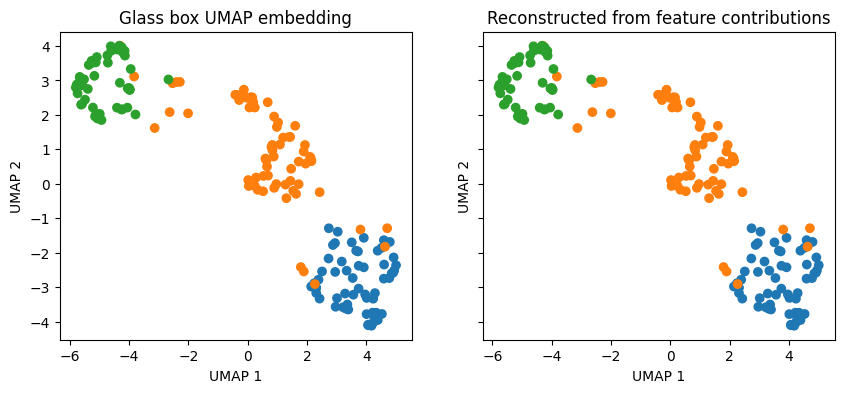

In [8]:
reconstructed = contributions.sum(axis=2)
is_equivalent = np.allclose(reconstructed, gb_umap_embedding, atol=1e-5)

print(f"Reconstruction matches embedding: {is_equivalent}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for a, Z, title in zip(ax, [gb_umap_embedding, reconstructed], ["Glass box UMAP embedding", "Reconstructed from feature contributions"]):
    s = a.scatter(Z[:, 0], Z[:, 1], c=[CULTIVAR_COLORS[t] for t in target])
    a.set(xlabel="UMAP 1", ylabel="UMAP 2", title=title)

plt.show()

## Interpreting contributions

How best to interpret feature contributions is dataset-dependent and an active area of research. The intention of this section is to provide one lens into how feature contributions can be interpreted, it is not to put forth an authoritative viewpoint on feature contribution interpretability in general.

We encourage you to creatively explore feature contributions in your own data, as we don't want to prescribe a single workflow. As perspectives in the community converge on clearer analyses, we can include them into the package. Until then, we have introduced an optional plotting utility that allows one to interactively explore feature contributions, though as a final reminder, please explore beyond the capabilities of this tool (and report back what you find!).

[plot_embedding](../autoapi/glass_box_umap/index.rst#glass_box_umap.plotting.plot_embedding) renders the embedding linked to a feature-contribution bar chart.

:::{admonition} Install the plotting extras
:class: tip dropdown

`glass_box_umap.plotting` is an optional dependency, that can be installed like so:

```bash
pip install "glass-box-umap[plotting]"
# or
uv pip install "glass-box-umap[plotting]"
```
:::

In [9]:
from glass_box_umap.plotting import (
    plot_embedding,
    show,
)

show(
    plot_embedding(
        Z=gb_umap_embedding,
        contributions=contributions,
        group_names=target,
        feature_names=wine.columns,
        feature_values=X,
    )
)

Two toggles drive what you see:

- Color by *(above the scatter)*:
    * `Group` colors points by labels you supply (here, cultivar)
    * `Feature` paints a gradient over the L2-reduced contribution of a single feature picked from an autocomplete
    * `Top feature` colors each point by whichever feature contributes most at that point

- View *(above the bar chart)*:
    * `L2` is the magnitude of each feature's contribution to embedding position (always non-negative)
    * `normed L2` is the same, however contributions are normalized per-sample such that they always sum to 1
    * `Dim 1` and `Dim 2` are the signed contributions to the corresponding embedding axis.

You can use the "Lasso" or "box-select" tools to restrict the bars to a custom cohort. With nothing selected, the bars summarize all samples.

---

Here are a few observations:

1. **Proline holds cultivar 0 together.** Switch *Color by* to **Top feature** and the bottom-right cluster lights up as proline. Lasso it and look at **normed L2**: proline accounts for ~17% of the average sample's reconstruction there, compared to ~8% and ~4% for cultivars 1 and 2.

2. **Flavanoids is a polarity feature: same magnitude, opposite sign at the two ends.** It has the largest mean L2 globally, but switching the bar chart to **Dim 1** and lassoing each cluster shows it flips sign. Strongly positive (push right) inside cultivar 0 and strongly negative (push left) inside cultivar 2. Switching *Color by* to **Feature**, selecting flavanoids, and hovering over datapoints in cultivars 0 and 2 reveal that the standard-normalized flavanoid values (i.e., values in `X` -- not `contributions`) are negative (below average) for cultivar 2 and positive (above average) for cultivar 0.

3. **Color intensity is uniquely prominent in cultivar 2**. Interestingly, members of cultivar 1 that leak towards the cultivar 2 cluster have upweighted color intensity contributions, further evidencing that color intensity is a unifying feature of the cultivar 2 cluster.

4. **Ash drives sub-clustering in cultivar 0**. Color by ash and notice the rightmost members of cultivar 0 light up. Lasso these points and see that ash is the dominant contributor of these points. This is despite the fact that proline and flavanoids are the dominant contributors of cultivar 0 as a whole. This suggests that features that separate a cluster from the others are not always the features that define local positioning of points within.

## Conclusion

`GlassBoxUMAP` behaves like any other UMAP implementation for fitting and transforming, and adds `compute_contributions`: a per-feature attribution that sums exactly to the embedding. `contributions` is just a NumPy array, safe to plug into any downstream analysis. The interactive plot used in this guide is one starting point.

From here, [Saving & Loading](saving_and_loading.ipynb) covers persisting fitted models to disk, and [Embedding Comparison](embedding_comparison.ipynb) compares Glass Box UMAP against standard UMAP on a variety of datasets.